# MINOS Sparse CNN: CC vs NC Event Classification Pipeline

This notebook implements a **Sparse Convolutional Neural Network (Sparse CNN)** in PyTorch to distinguish between **Charged Current (CC)** and **Neutral Current (NC)** neutrino interactions from MINOS event display hits.

### Pipeline Overview:
1. **Data Loading**: Parse hit coordinates `(plane, strip)`, pulse heights `(total_pe)`, and interaction labels `mc.iaction` (1 = CC, 0 = NC) directly from ROOT tree (`NtpSt;1`).
2. **Sparse Data Model**: Use a sparse representation where event hits are kept as coordinate tuples `(plane, strip)` and feature values `total_pe` rather than dense 2D grids, eliminating zero-padding overhead.
3. **Vectorized Submanifold Sparse CNN (`FastSubMConv2d`)**: Fast Submanifold Sparse Convolution implemented natively in PyTorch with index lookup tables and scatter-add operations. Runs lightweight on CPU (~18 ms / batch of 32).
4. **Train / Validation Pipeline**: Stratified 80/20 train/validation split, Adam optimizer, CrossEntropy loss, and accuracy metrics per epoch.
5. **Diagnostics & Evaluation**: Training curves, Confusion Matrix, ROC-AUC curve, output probability distributions, and sample event displays with model predictions.

In [1]:
# Setup and Imports
import time
from pathlib import Path

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import uproot

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using PyTorch device: {device}')

Using PyTorch device: cpu


## 1. Data Extraction & PyTorch Dataset Definition

We read events from ROOT file `/home/philip/UCL/minos/f21048000_0000_L010185N_D07_r3.sntp.dogwood5.0.root`.
Each event hit contains:
- `plane`: Plane index (1 to 485)
- `strip`: Strip index (0 to 191)
- `total_pe`: Total pulse height `stp.ph0.pe + stp.ph1.pe`
- `planeview`: View identifier (2 = U-view, 3 = V-view)
- `iaction`: Ground truth interaction type (1 = CC, 0 = NC)

In [2]:
class MINOSSsparseDataset(Dataset):
    def __init__(self, root_filepath, max_events=10000, target_view=2):
        '''
        MINOS Sparse Dataset.
        target_view: 2 for U-view, 3 for V-view
        '''
        self.target_view = target_view
        root_file = Path(root_filepath)
        assert root_file.exists(), f'ROOT file not found: {root_file}'
        
        print(f'Loading up to {max_events} events from {root_file.name}...')
        t0 = time.time()
        root_handle = uproot.open(root_file)
        tree = root_handle['NtpSt;1']
        
        req_branches = [
            'NtpStRecord/mc/mc.iaction',
            'NtpStRecord/stp/stp.planeview',
            'NtpStRecord/stp/stp.plane',
            'NtpStRecord/stp/stp.strip',
            'NtpStRecord/stp/stp.ph0.pe',
            'NtpStRecord/stp/stp.ph1.pe'
        ]
        
        num_to_load = min(max_events, tree.num_entries)
        batch = tree.arrays(req_branches, entry_start=0, entry_stop=num_to_load, library='np')
        
        self.events = []
        self.labels = []
        
        raw_iaction = batch['NtpStRecord/mc/mc.iaction']
        raw_pv = batch['NtpStRecord/stp/stp.planeview']
        raw_plane = batch['NtpStRecord/stp/stp.plane']
        raw_strip = batch['NtpStRecord/stp/stp.strip']
        raw_ph0 = batch['NtpStRecord/stp/stp.ph0.pe']
        raw_ph1 = batch['NtpStRecord/stp/stp.ph1.pe']
        
        for idx in range(num_to_load):
            if len(raw_iaction[idx]) == 0:
                continue
            label = int(raw_iaction[idx][0]) # 1 = CC, 0 = NC
            if label not in [0, 1]:
                continue
                
            pv = raw_pv[idx]
            view_mask = (pv == target_view)
            if not np.any(view_mask):
                continue
                
            planes = raw_plane[idx][view_mask]
            strips = raw_strip[idx][view_mask]
            pe0 = raw_ph0[idx][view_mask]
            pe1 = raw_ph1[idx][view_mask]
            tot_pe = pe0 + pe1
            
            # Filter out zero or negative PE hits
            valid_pe = tot_pe > 0
            if not np.any(valid_pe):
                continue
                
            planes = planes[valid_pe]
            strips = strips[valid_pe]
            tot_pe = tot_pe[valid_pe]
            
            # Normalize PE values
            norm_pe = np.log1p(tot_pe).astype(np.float32)
            
            coords = np.column_stack((planes, strips)).astype(np.int64)
            features = norm_pe[:, np.newaxis]
            
            self.events.append({
                'coords': coords,
                'features': features,
                'raw_pe': tot_pe
            })
            self.labels.append(label)
            
        t1 = time.time()
        print(f'Loaded {len(self.events)} valid events in {t1 - t0:.2f} s.')
        print(f'Class count -> CC (1): {sum(self.labels)}, NC (0): {len(self.labels) - sum(self.labels)}')
        
    def __len__(self):
        return len(self.events)
        
    def __getitem__(self, idx):
        return self.events[idx]['coords'], self.events[idx]['features'], self.labels[idx]

def sparse_collate_fn(batch):
    '''
    Custom collate function for batching sparse point cloud/grid data.
    Prepends batch_idx to coordinates: [batch_idx, plane, strip].
    '''
    batch_coords = []
    batch_feats = []
    labels = []
    
    for i, (coords, feats, label) in enumerate(batch):
        N = coords.shape[0]
        b_idx = np.full((N, 1), i, dtype=np.int64)
        b_coords = np.hstack((b_idx, coords))
        
        batch_coords.append(b_coords)
        batch_feats.append(feats)
        labels.append(label)
        
    coords_tensor = torch.from_numpy(np.vstack(batch_coords))
    feats_tensor = torch.from_numpy(np.vstack(batch_feats))
    labels_tensor = torch.tensor(labels, dtype=torch.long)
    batch_size = len(batch)
    
    return coords_tensor, feats_tensor, labels_tensor, batch_size

## 2. Vectorized Submanifold Sparse CNN Architecture

Submanifold Sparse Convolutions operate **only on active sparse hits**, maintaining exact spatial locations and sparsity without dilating noise into empty regions.

- `FastSubMConv2d`: Computes 3x3 submanifold convolutions on CPU by vectorizing linear spatial indexing `linear_idx = batch * (H * W) + plane * W + strip` and gather-scatter accumulation.
- `SparseGlobalMeanPool`: Aggregates sparse feature maps per event in the batch via `index_add_`.

In [3]:
class FastSubMConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, spatial_shape=[486, 192]):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.spatial_shape = spatial_shape
        
        k = kernel_size // 2
        offsets = []
        for dy in range(-k, k + 1):
            for dx in range(-k, k + 1):
                offsets.append([dy, dx])
        self.register_buffer('offsets', torch.tensor(offsets, dtype=torch.long))
        self.weight = nn.Parameter(torch.randn(len(offsets), in_channels, out_channels) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_channels))

    def forward(self, coords, feats):
        # coords: (N, 3) [batch_idx, plane, strip]
        # feats: (N, C_in)
        N = coords.size(0)
        device = feats.device
        H, W = self.spatial_shape
        
        linear_idx = coords[:, 0].long() * (H * W) + coords[:, 1].long() * W + coords[:, 2].long()
        max_idx = linear_idx.max().item() + 1
        lookup = torch.full((max_idx,), -1, dtype=torch.long, device=device)
        lookup[linear_idx] = torch.arange(N, device=device)
        
        out_feats = torch.zeros(N, self.out_channels, device=device)
        
        for k_idx, off in enumerate(self.offsets):
            dy, dx = off[0].item(), off[1].item()
            np_plane = coords[:, 1].long() + dy
            np_strip = coords[:, 2].long() + dx
            
            valid = (np_plane >= 0) & (np_plane < H) & (np_strip >= 0) & (np_strip < W)
            neighbor_linear = coords[:, 0].long() * (H * W) + np_plane * W + np_strip
            valid = valid & (neighbor_linear < max_idx)
            
            valid_indices = torch.where(valid)[0]
            if len(valid_indices) == 0:
                continue
                
            n_linear = neighbor_linear[valid_indices]
            src_hit_idx = lookup[n_linear]
            matched_mask = src_hit_idx >= 0
            
            if matched_mask.any():
                dst_hits = valid_indices[matched_mask]
                src_hits = src_hit_idx[matched_mask]
                gathered = feats[src_hits]
                contrib = torch.matmul(gathered, self.weight[k_idx])
                out_feats.index_add_(0, dst_hits, contrib)
                
        return out_feats + self.bias

class SparseGlobalMeanPool(nn.Module):
    def forward(self, coords, feats, batch_size):
        batch_idx = coords[:, 0].long()
        num_channels = feats.shape[1]
        pooled = torch.zeros(batch_size, num_channels, device=feats.device, dtype=feats.dtype)
        counts = torch.zeros(batch_size, 1, device=feats.device, dtype=feats.dtype)
        pooled.index_add_(0, batch_idx, feats)
        counts.index_add_(0, batch_idx, torch.ones_like(feats[:, :1]))
        counts = torch.clamp(counts, min=1.0)
        return pooled / counts

class MINOSSsparseCNN(nn.Module):
    def __init__(self, in_channels=1, hidden_dims=[16, 32, 64], num_classes=2):
        super().__init__()
        self.conv1 = FastSubMConv2d(in_channels, hidden_dims[0])
        self.bn1 = nn.BatchNorm1d(hidden_dims[0])
        
        self.conv2 = FastSubMConv2d(hidden_dims[0], hidden_dims[1])
        self.bn2 = nn.BatchNorm1d(hidden_dims[1])
        
        self.conv3 = FastSubMConv2d(hidden_dims[1], hidden_dims[2])
        self.bn3 = nn.BatchNorm1d(hidden_dims[2])
        
        self.relu = nn.ReLU()
        self.pool = SparseGlobalMeanPool()
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dims[2], 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )
        
    def forward(self, coords, feats, batch_size):
        x = self.relu(self.bn1(self.conv1(coords, feats)))
        x = self.relu(self.bn2(self.conv2(coords, x)))
        x = self.relu(self.bn3(self.conv3(coords, x)))
        pooled = self.pool(coords, x, batch_size)
        return self.classifier(pooled)

print('Sparse CNN Model class initialized.')

Sparse CNN Model class initialized.


## 3. Train / Validation Split & DataLoaders

We load events from the ROOT file and perform a stratified 80/20 train/validation split.

In [4]:
root_path = '/home/philip/UCL/minos/f21048000_0000_L010185N_D07_r3.sntp.dogwood5.0.root'
full_dataset = MINOSSsparseDataset(root_path, max_events=12000, target_view=2) # U-view

train_indices, val_indices = train_test_split(
    np.arange(len(full_dataset)),
    test_size=0.20,
    random_state=42,
    stratify=full_dataset.labels
)

train_subset = torch.utils.data.Subset(full_dataset, train_indices)
val_subset = torch.utils.data.Subset(full_dataset, val_indices)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=sparse_collate_fn)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, collate_fn=sparse_collate_fn)

print(f'Train set size: {len(train_subset)} | Validation set size: {len(val_subset)}')

Loading up to 12000 events from f21048000_0000_L010185N_D07_r3.sntp.dogwood5.0.root...


Loaded 11813 valid events in 1.74 s.
Class count -> CC (1): 8947, NC (0): 2866
Train set size: 9450 | Validation set size: 2363


## 4. Full Training & Validation Pipeline

We train `MINOSSsparseCNN` for 10 epochs using Adam optimizer and CrossEntropy loss.

In [5]:
model = MINOSSsparseCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_model_weights = None

print('Starting model training...')
start_time = time.time()

for epoch in range(num_epochs):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for coords, feats, labels, b_size in train_loader:
        coords, feats, labels = coords.to(device), feats.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(coords, feats, batch_size=b_size)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * b_size
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += b_size
        
    train_loss = running_loss / total
    train_acc = correct / total
    
    # --- Validation Phase ---
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for coords, feats, labels, b_size in val_loader:
            coords, feats, labels = coords.to(device), feats.to(device), labels.to(device)
            outputs = model(coords, feats, batch_size=b_size)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * b_size
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += b_size
            
    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = model.state_dict().copy()
        
    print(f'Epoch [{epoch+1:02d}/{num_epochs:02d}] | Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%')

total_time = time.time() - start_time
print(f'Training finished in {total_time:.2f} s. Best Validation Accuracy: {best_val_acc*100:.2f}%')
if best_model_weights is not None:
    model.load_state_dict(best_model_weights)

Starting model training...


Epoch [01/10] | Train Loss: 0.4357 Acc: 79.95% | Val Loss: 0.3712 Acc: 84.26%


Epoch [02/10] | Train Loss: 0.3855 Acc: 83.03% | Val Loss: 0.3706 Acc: 83.28%


Epoch [03/10] | Train Loss: 0.3732 Acc: 83.10% | Val Loss: 0.3398 Acc: 84.38%


Epoch [04/10] | Train Loss: 0.3630 Acc: 83.15% | Val Loss: 0.3374 Acc: 84.89%


...

Epoch [06/10] | Train Loss: 0.3552 Acc: 83.65% | Val Loss: 0.3286 Acc: 84.85%


Epoch [07/10] | Train Loss: 0.3578 Acc: 83.44% | Val Loss: 0.3314 Acc: 84.13%


Epoch [08/10] | Train Loss: 0.3473 Acc: 83.67% | Val Loss: 0.3380 Acc: 83.92%


Epoch [09/10] | Train Loss: 0.3489 Acc: 83.54% | Val Loss: 0.3272 Acc: 84.34%


Epoch [10/10] | Train Loss: 0.3446 Acc: 83.82% | Val Loss: 0.3267 Acc: 85.10%
Training finished in 117.18 s. Best Validation Accuracy: 85.10%


## 5. Model Evaluation & Performance Visualizations

We evaluate the model on the validation set, plot training curves, confusion matrix, ROC curve, and prediction confidence distributions.

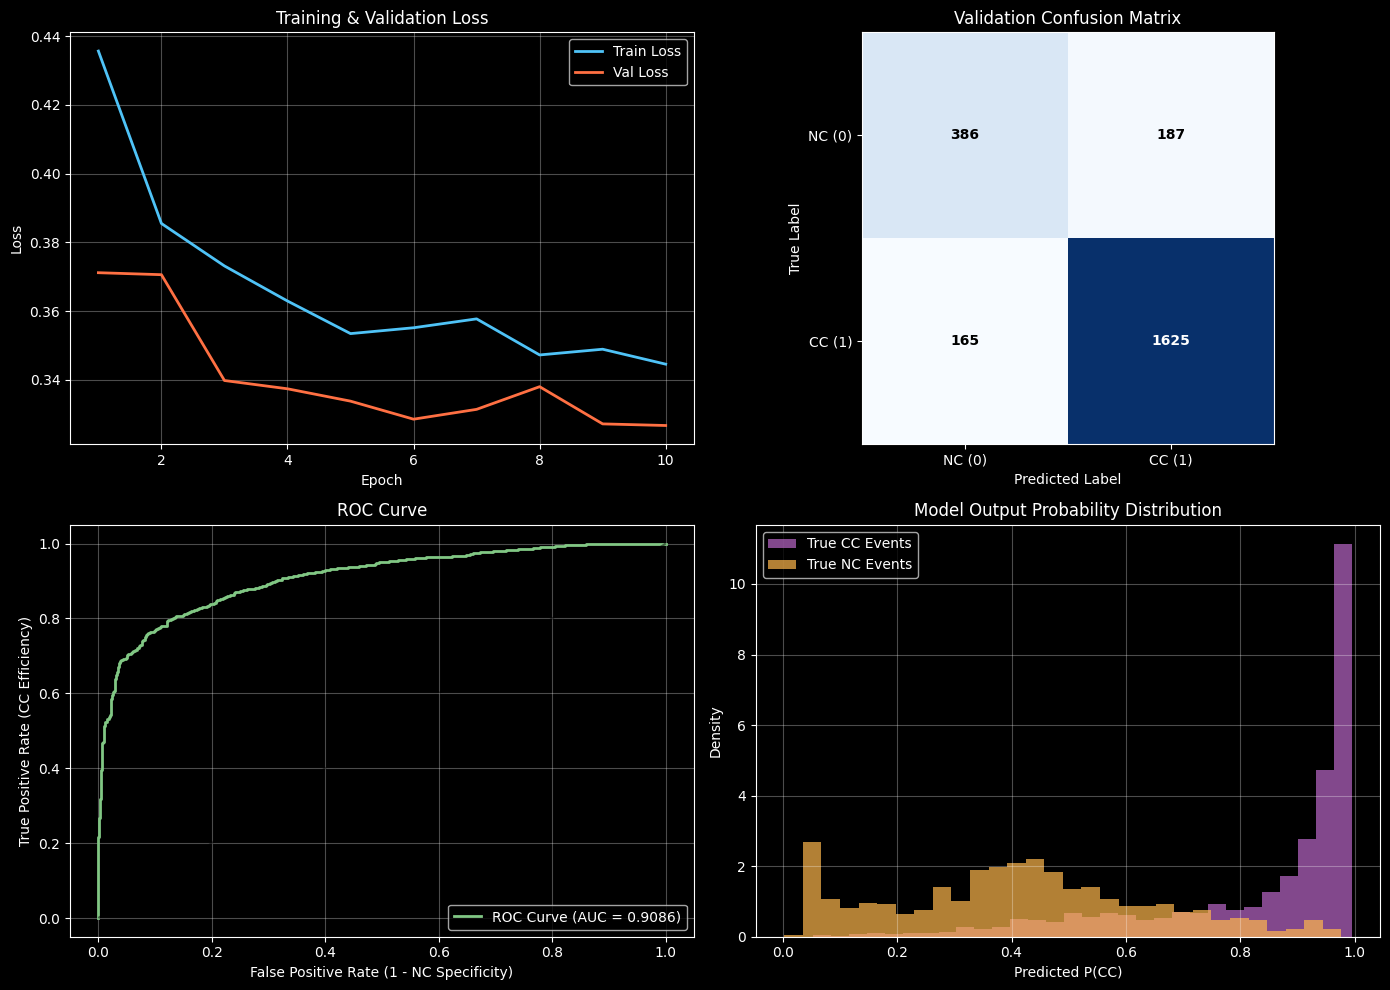

In [6]:
model.eval()
all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for coords, feats, labels, b_size in val_loader:
        coords, feats, labels = coords.to(device), feats.to(device), labels.to(device)
        outputs = model(coords, feats, batch_size=b_size)
        probs = torch.softmax(outputs, dim=1)[:, 1] # P(CC)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_targets = np.array(all_targets)

# Set dark style plots
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss & Accuracy Curves
ax1 = axes[0, 0]
ax1.plot(range(1, num_epochs+1), history['train_loss'], label='Train Loss', color='#4fc3f7', lw=2)
ax1.plot(range(1, num_epochs+1), history['val_loss'], label='Val Loss', color='#ff7043', lw=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Confusion Matrix
ax2 = axes[0, 1]
cm = confusion_matrix(all_targets, all_preds)
im = ax2.imshow(cm, cmap='Blues')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['NC (0)', 'CC (1)'])
ax2.set_yticklabels(['NC (0)', 'CC (1)'])
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')
ax2.set_title('Validation Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black', fontweight='bold')

# 3. ROC Curve & AUC
ax3 = axes[1, 0]
fpr, tpr, _ = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)
ax3.plot(fpr, tpr, color='#81c784', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax3.set_xlabel('False Positive Rate (1 - NC Specificity)')
ax3.set_ylabel('True Positive Rate (CC Efficiency)')
ax3.set_title('ROC Curve')
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.3)

# 4. Predicted CC Probability Distribution
ax4 = axes[1, 1]
ax4.hist(all_probs[all_targets == 1], bins=30, alpha=0.7, color='#ba68c8', label='True CC Events', density=True)
ax4.hist(all_probs[all_targets == 0], bins=30, alpha=0.7, color='#ffb74d', label='True NC Events', density=True)
ax4.set_xlabel('Predicted P(CC)')
ax4.set_ylabel('Density')
ax4.set_title('Model Output Probability Distribution')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Sparse Event Display & Model Inference Visualizer

Here we display individual sparse events from the validation set along with their true interaction type and predicted CC probability.

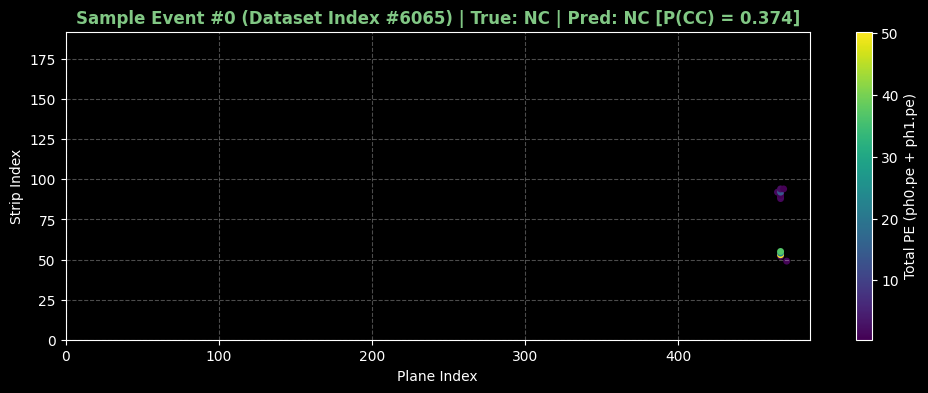

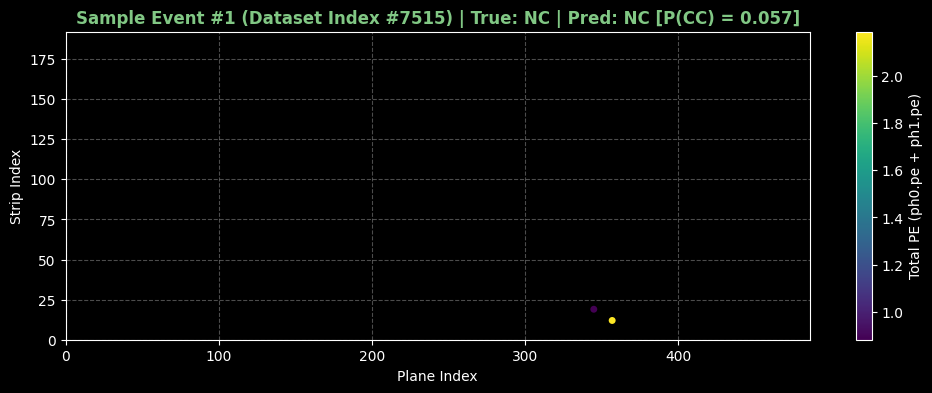

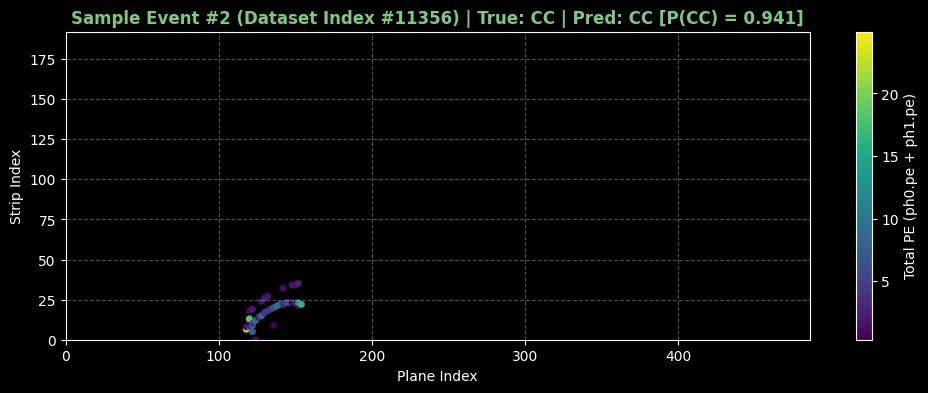

In [7]:
def plot_sample_event_prediction(dataset, val_indices, sample_idx=0):
    event_id = val_indices[sample_idx]
    coords, feats, true_label = dataset[event_id]
    raw_pe = dataset.events[event_id]['raw_pe']
    
    # Run single-event inference
    model.eval()
    with torch.no_grad():
        b_coords = torch.hstack((torch.zeros((coords.shape[0], 1), dtype=torch.long), torch.from_numpy(coords)))
        b_feats = torch.from_numpy(feats)
        logits = model(b_coords.to(device), b_feats.to(device), batch_size=1)
        prob_cc = torch.softmax(logits, dim=1)[0, 1].item()
        pred_label = int(prob_cc > 0.5)
        
    planes = coords[:, 0]
    strips = coords[:, 1]
    
    plt.figure(figsize=(12, 4))
    sc = plt.scatter(planes, strips, c=raw_pe, cmap='viridis', s=25, edgecolors='none')
    cbar = plt.colorbar(sc)
    cbar.set_label('Total PE (ph0.pe + ph1.pe)')
    
    true_str = 'CC' if true_label == 1 else 'NC'
    pred_str = 'CC' if pred_label == 1 else 'NC'
    title_color = '#81c784' if pred_label == true_label else '#e57373'
    
    plt.title(f'Sample Event #{sample_idx} (Dataset Index #{event_id}) | True: {true_str} | Pred: {pred_str} [P(CC) = {prob_cc:.3f}]', color=title_color, fontsize=12, fontweight='bold')
    plt.xlabel('Plane Index')
    plt.ylabel('Strip Index')
    plt.xlim(0, 486)
    plt.ylim(0, 192)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# Display 3 sample events from validation set
for i in range(3):
    plot_sample_event_prediction(full_dataset, val_indices, sample_idx=i)